# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.


In [5]:
# Crating database connection
conn = sqlite3.connect('inventory.db')

# Loading data from the database
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,PurchasePrice,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,26.27,36.99,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,23.19,28.99,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,18.24,24.99,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,16.17,22.99,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,21.89,29.99,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis

- Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [7]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10648.0,10640.705203,18700.404409,2.000000,3943.500000,7153.000000,9552.000000,1.733570e+05
Brand,10648.0,18054.503193,12643.196784,58.000000,5816.500000,18776.500000,25521.250000,9.063100e+04
PurchasePrice,10648.0,24.402095,109.483355,0.360000,6.840000,10.450000,19.470000,5.681810e+03
ActualPrice,10648.0,35.671184,148.534066,0.490000,10.990000,15.990000,28.990000,7.499990e+03
TotalPurchaseQuantity,10648.0,3145.159936,11113.367455,1.000000,36.000000,261.000000,1981.250000,3.376600e+05
TotalPurchaseDollars,10648.0,30138.163064,123277.154715,0.710000,452.857500,3646.725000,20764.170000,3.811252e+06
TotalSalesQuantity,10648.0,3081.902047,10971.073340,0.000000,33.000000,260.500000,1934.250000,3.349390e+05
TotalSalesDollars,10648.0,42302.921643,167947.264974,0.000000,728.275000,5285.915000,28414.050000,5.101920e+06
TotalSalesPrice,10648.0,18813.647626,45018.406384,0.000000,288.830000,2841.775000,16080.270000,6.728193e+05
TotalExciseTax,10648.0,1775.333762,10992.438862,0.000000,4.800000,46.355000,418.375000,3.682428e+05


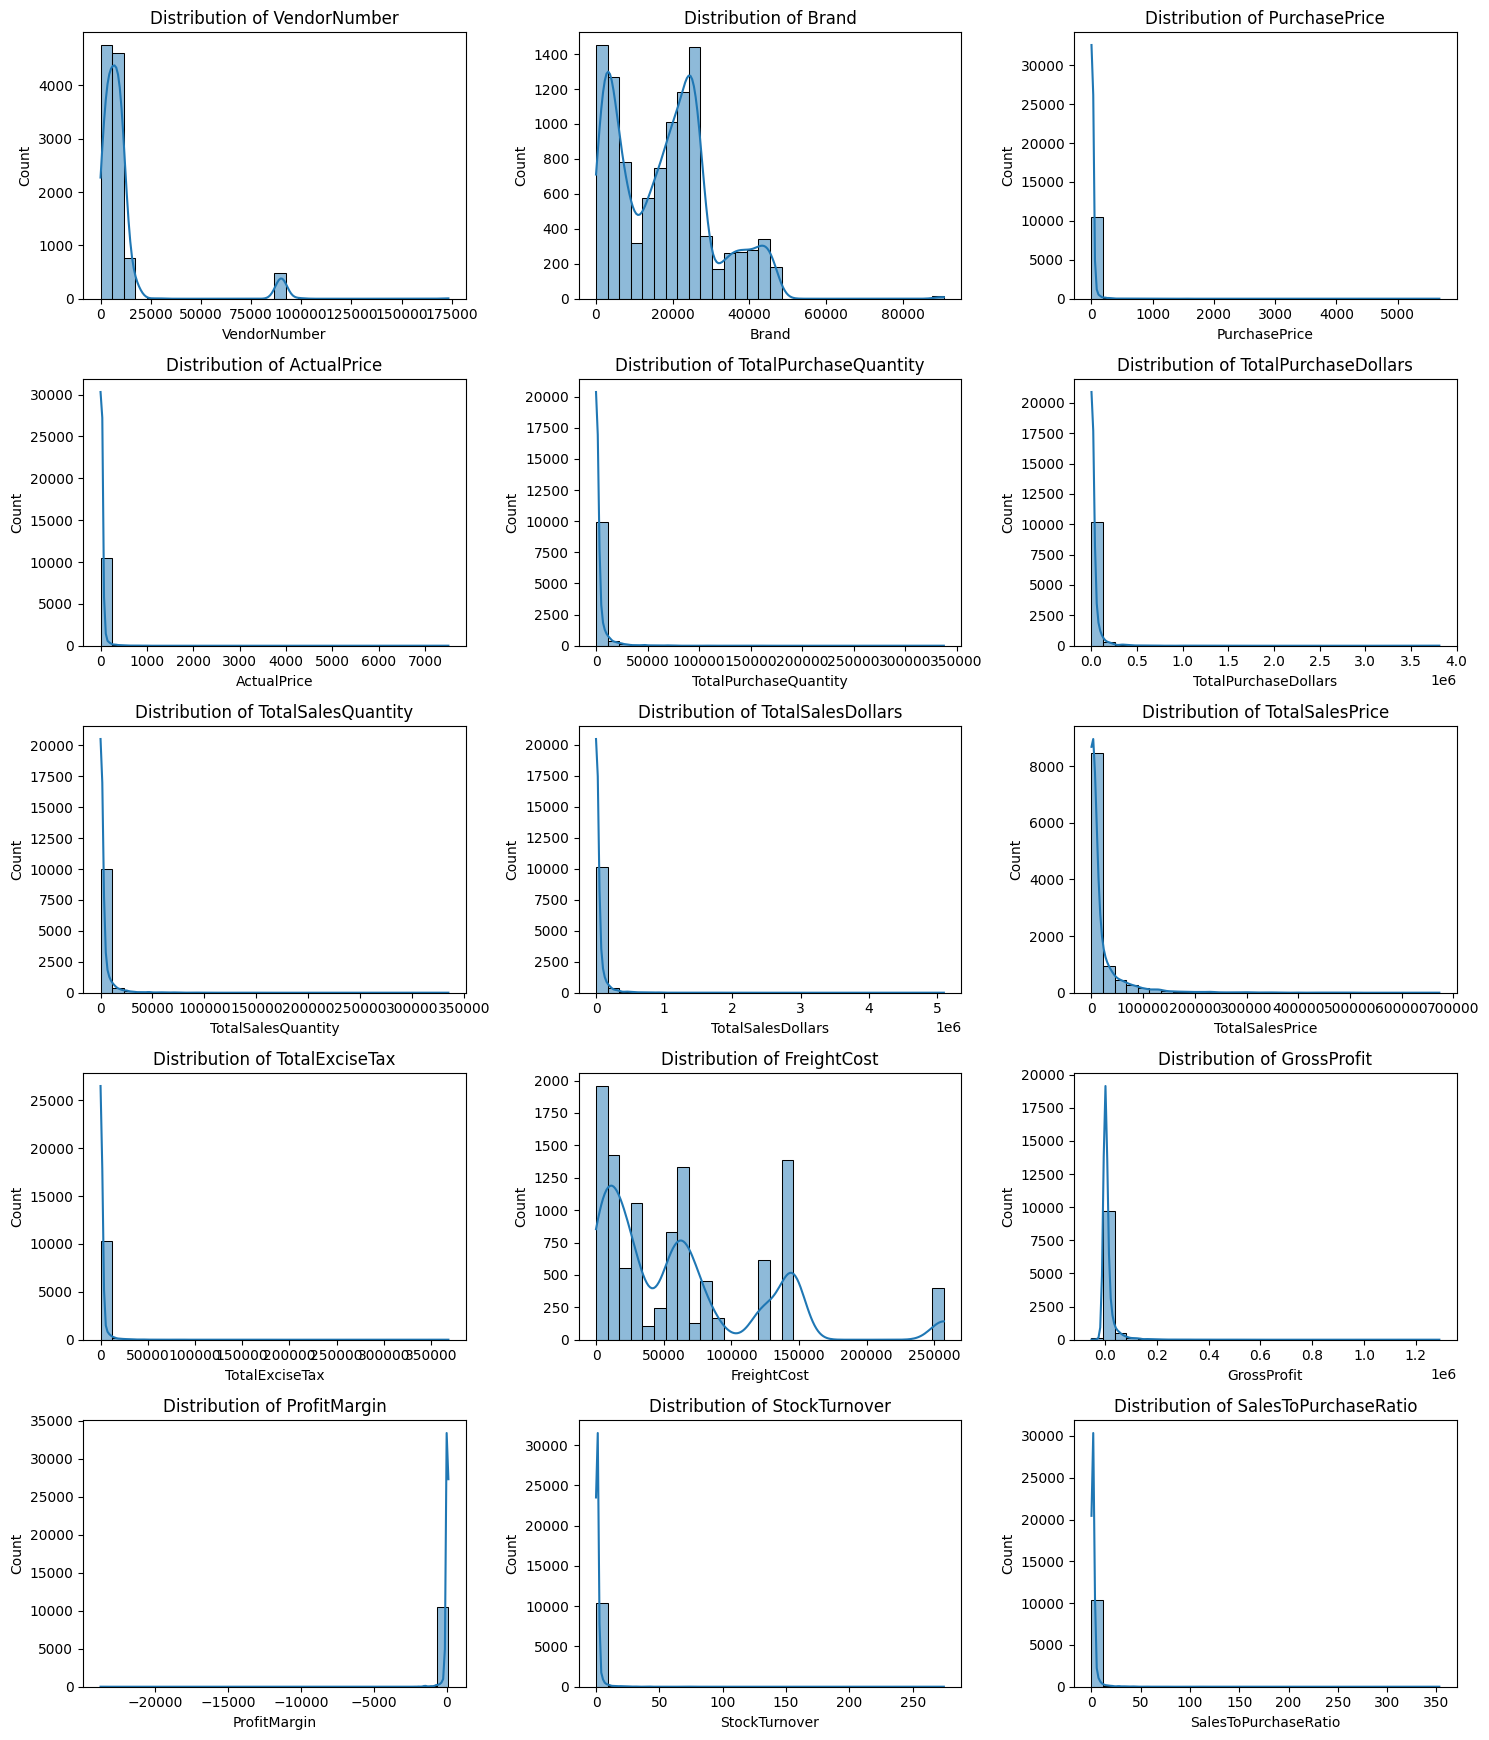

In [11]:
# Distribution plots for numeric features
numerical_col = df.select_dtypes(include=np.number).columns

n = len(numerical_col)
ncols = 3
nrows = int(np.ceil(n / ncols)) if n > 0 else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numerical_col):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(numerical_col), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

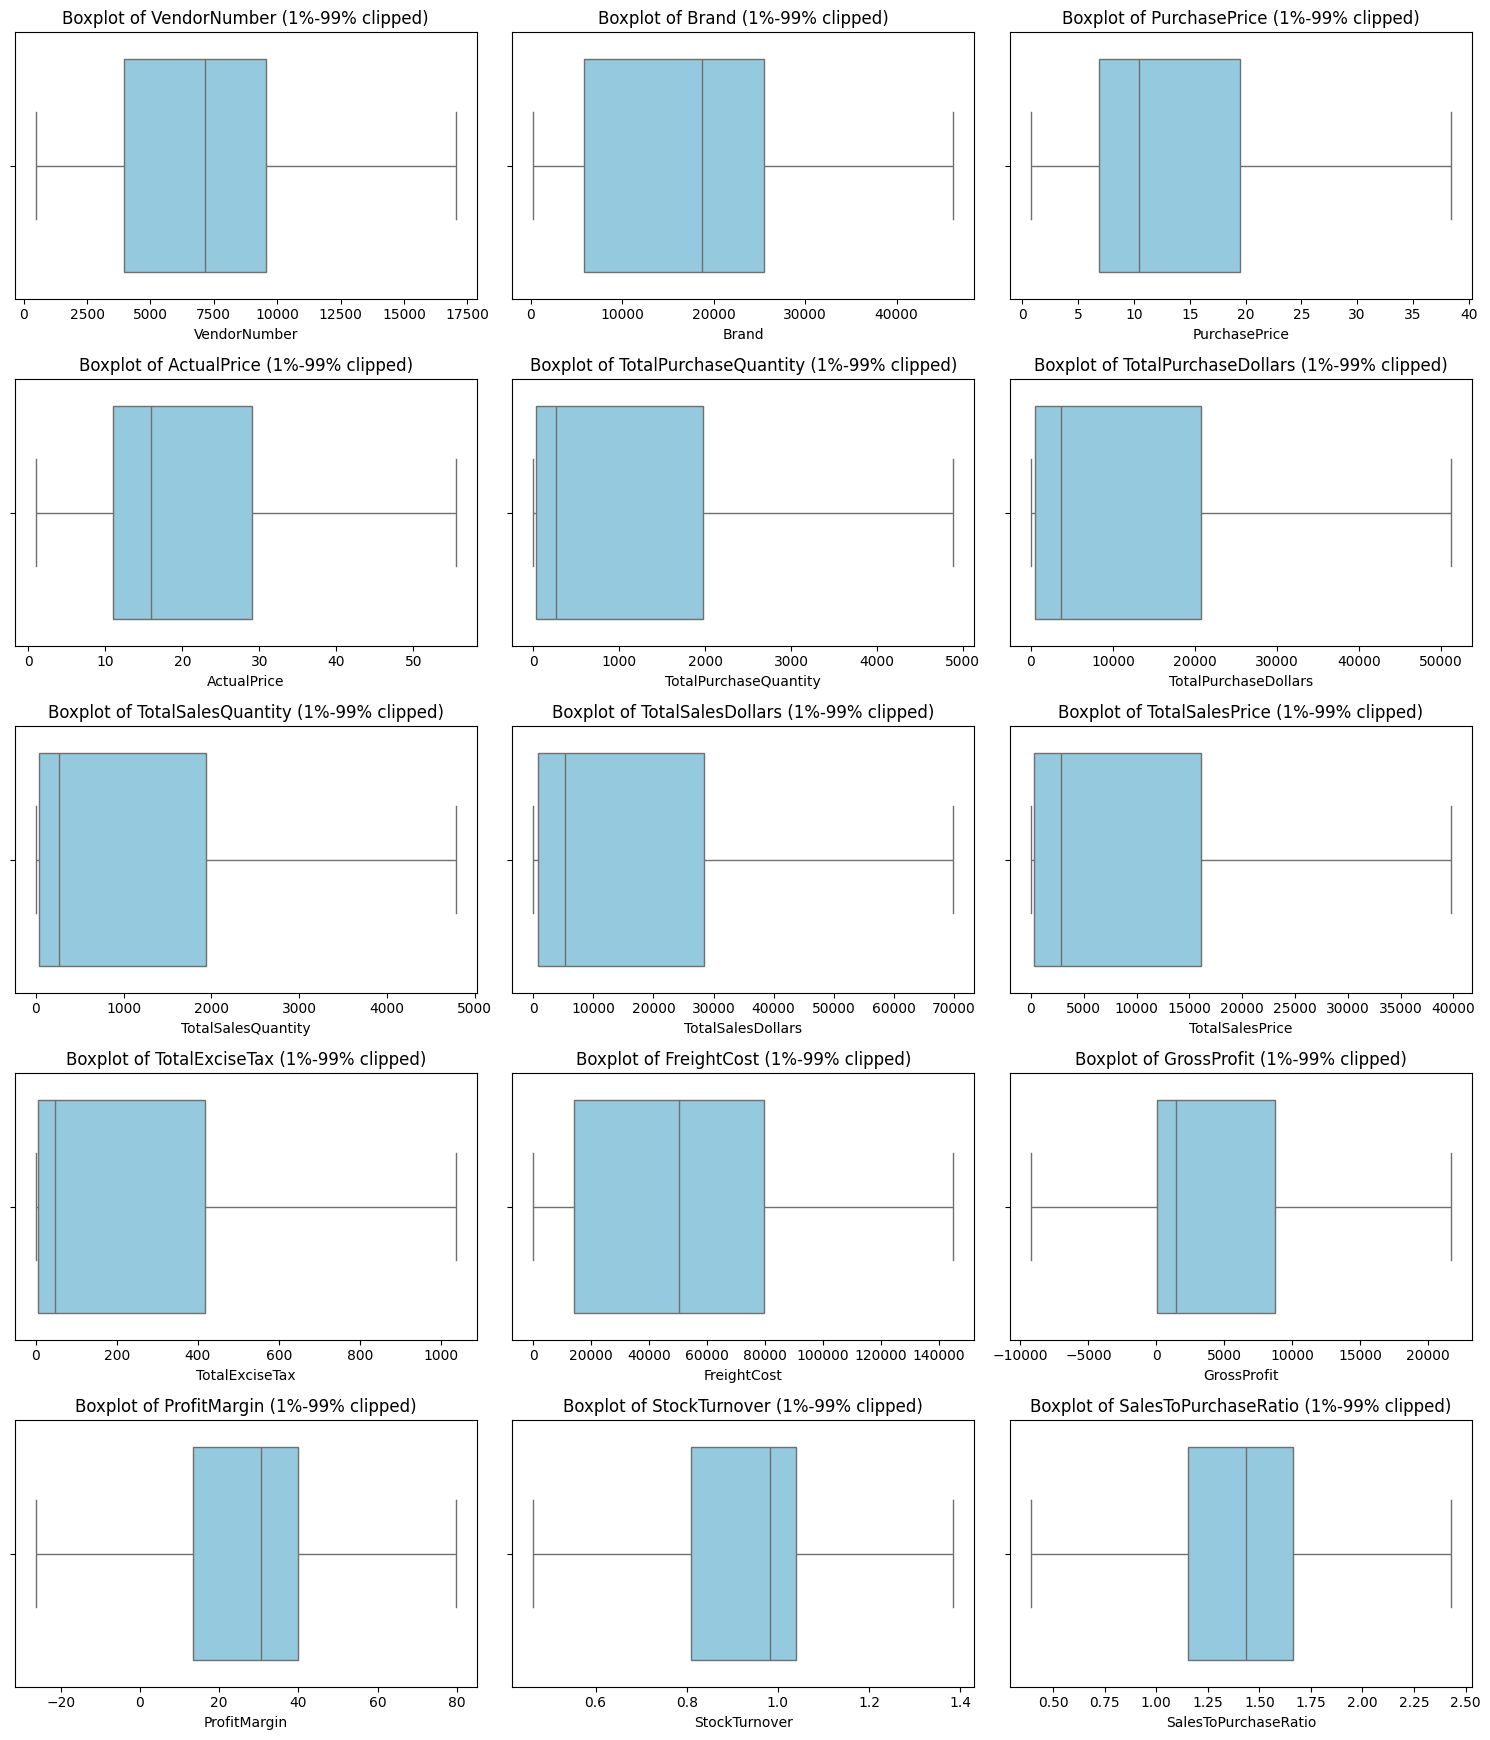

In [14]:
# Boxplots with outlier clipping (1st-99th percentile)
num_cols = df.select_dtypes(include=np.number).columns

n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols)) if n > 0 else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    series = df[col].dropna()
    lower = series.quantile(0.01)
    upper = series.quantile(0.99)
    clipped = series.clip(lower=lower, upper=upper)

    sns.boxplot(x=clipped, ax=axes[i], color="skyblue", showfliers=False)
    axes[i].set_title(f"Boxplot of {col} (1%-99% clipped)")
    axes[i].set_xlabel(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Summary Statistics Insights

### Negative & Zero Values

- **Gross Profit:** Minimum value is **-52,002.78**, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.

- **Profit Margin:** Has a minimum of **-∞**, which suggests cases where revenue is zero or even lower than costs.

- **Total Sales Quantity & Sales Dollars:** Minimum values are **0**, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

---

### Outliers Indicated by High Standard Deviations

- **Purchase & Actual Prices:** The max values (**5,681.81 & 7,499.99**) are significantly higher than the mean (**24.39 & 35.64**), indicating potential premium products.

- **Freight Cost:** Huge variation, from **0.09 to 257,032.07**, suggests logistics inefficiencies or bulk shipments.

- **Stock Turnover:** Ranges from **0 to 274.5**, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales being fulfilled from older stock.